In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [30]:
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')
df_original = pd.read_csv('data/Rainfall.csv')

In [31]:
df_train.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


We are dealing with circular data such as column 'day' and 'wind direction'. We want to transform them using sin() and cos() functions. This helps capture the cyclical relationship in a continuous way, ensuring that values at the “ends” of the cycle are close together.

In [32]:
df_train['day'].unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

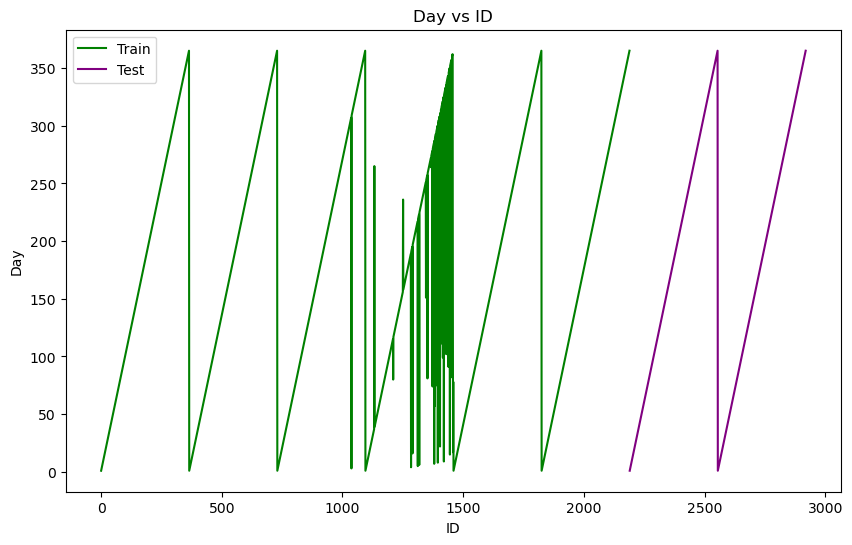

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(df_train['id'], df_train['day'], label='Train', color='green')
plt.plot(df_test['id'], df_test['day'], label='Test', color='purple')
plt.title('Day vs ID')
plt.xlabel('ID')
plt.ylabel('Day')
plt.legend()
plt.show()

We were expecting a circular pattern in the plot above. We can see that the days are not in order, but we can see that the pattern is cyclical. We can repair this by transforming the 'day' column.

In [34]:
# Transform day column so that id matches the day
df_train['day_repaired'] = df_train['id'] % 365

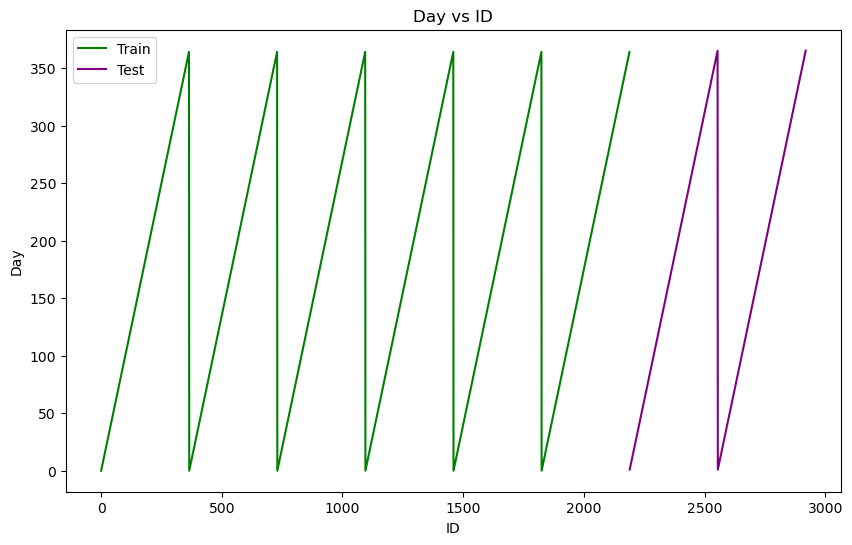

In [35]:
plt.figure(figsize=(10, 6))
plt.plot(df_train['id'], df_train['day_repaired'], label='Train', color='green')
plt.plot(df_test['id'], df_test['day'], label='Test', color='purple')
plt.title('Day vs ID')
plt.xlabel('ID')
plt.ylabel('Day')
plt.legend()
plt.show()

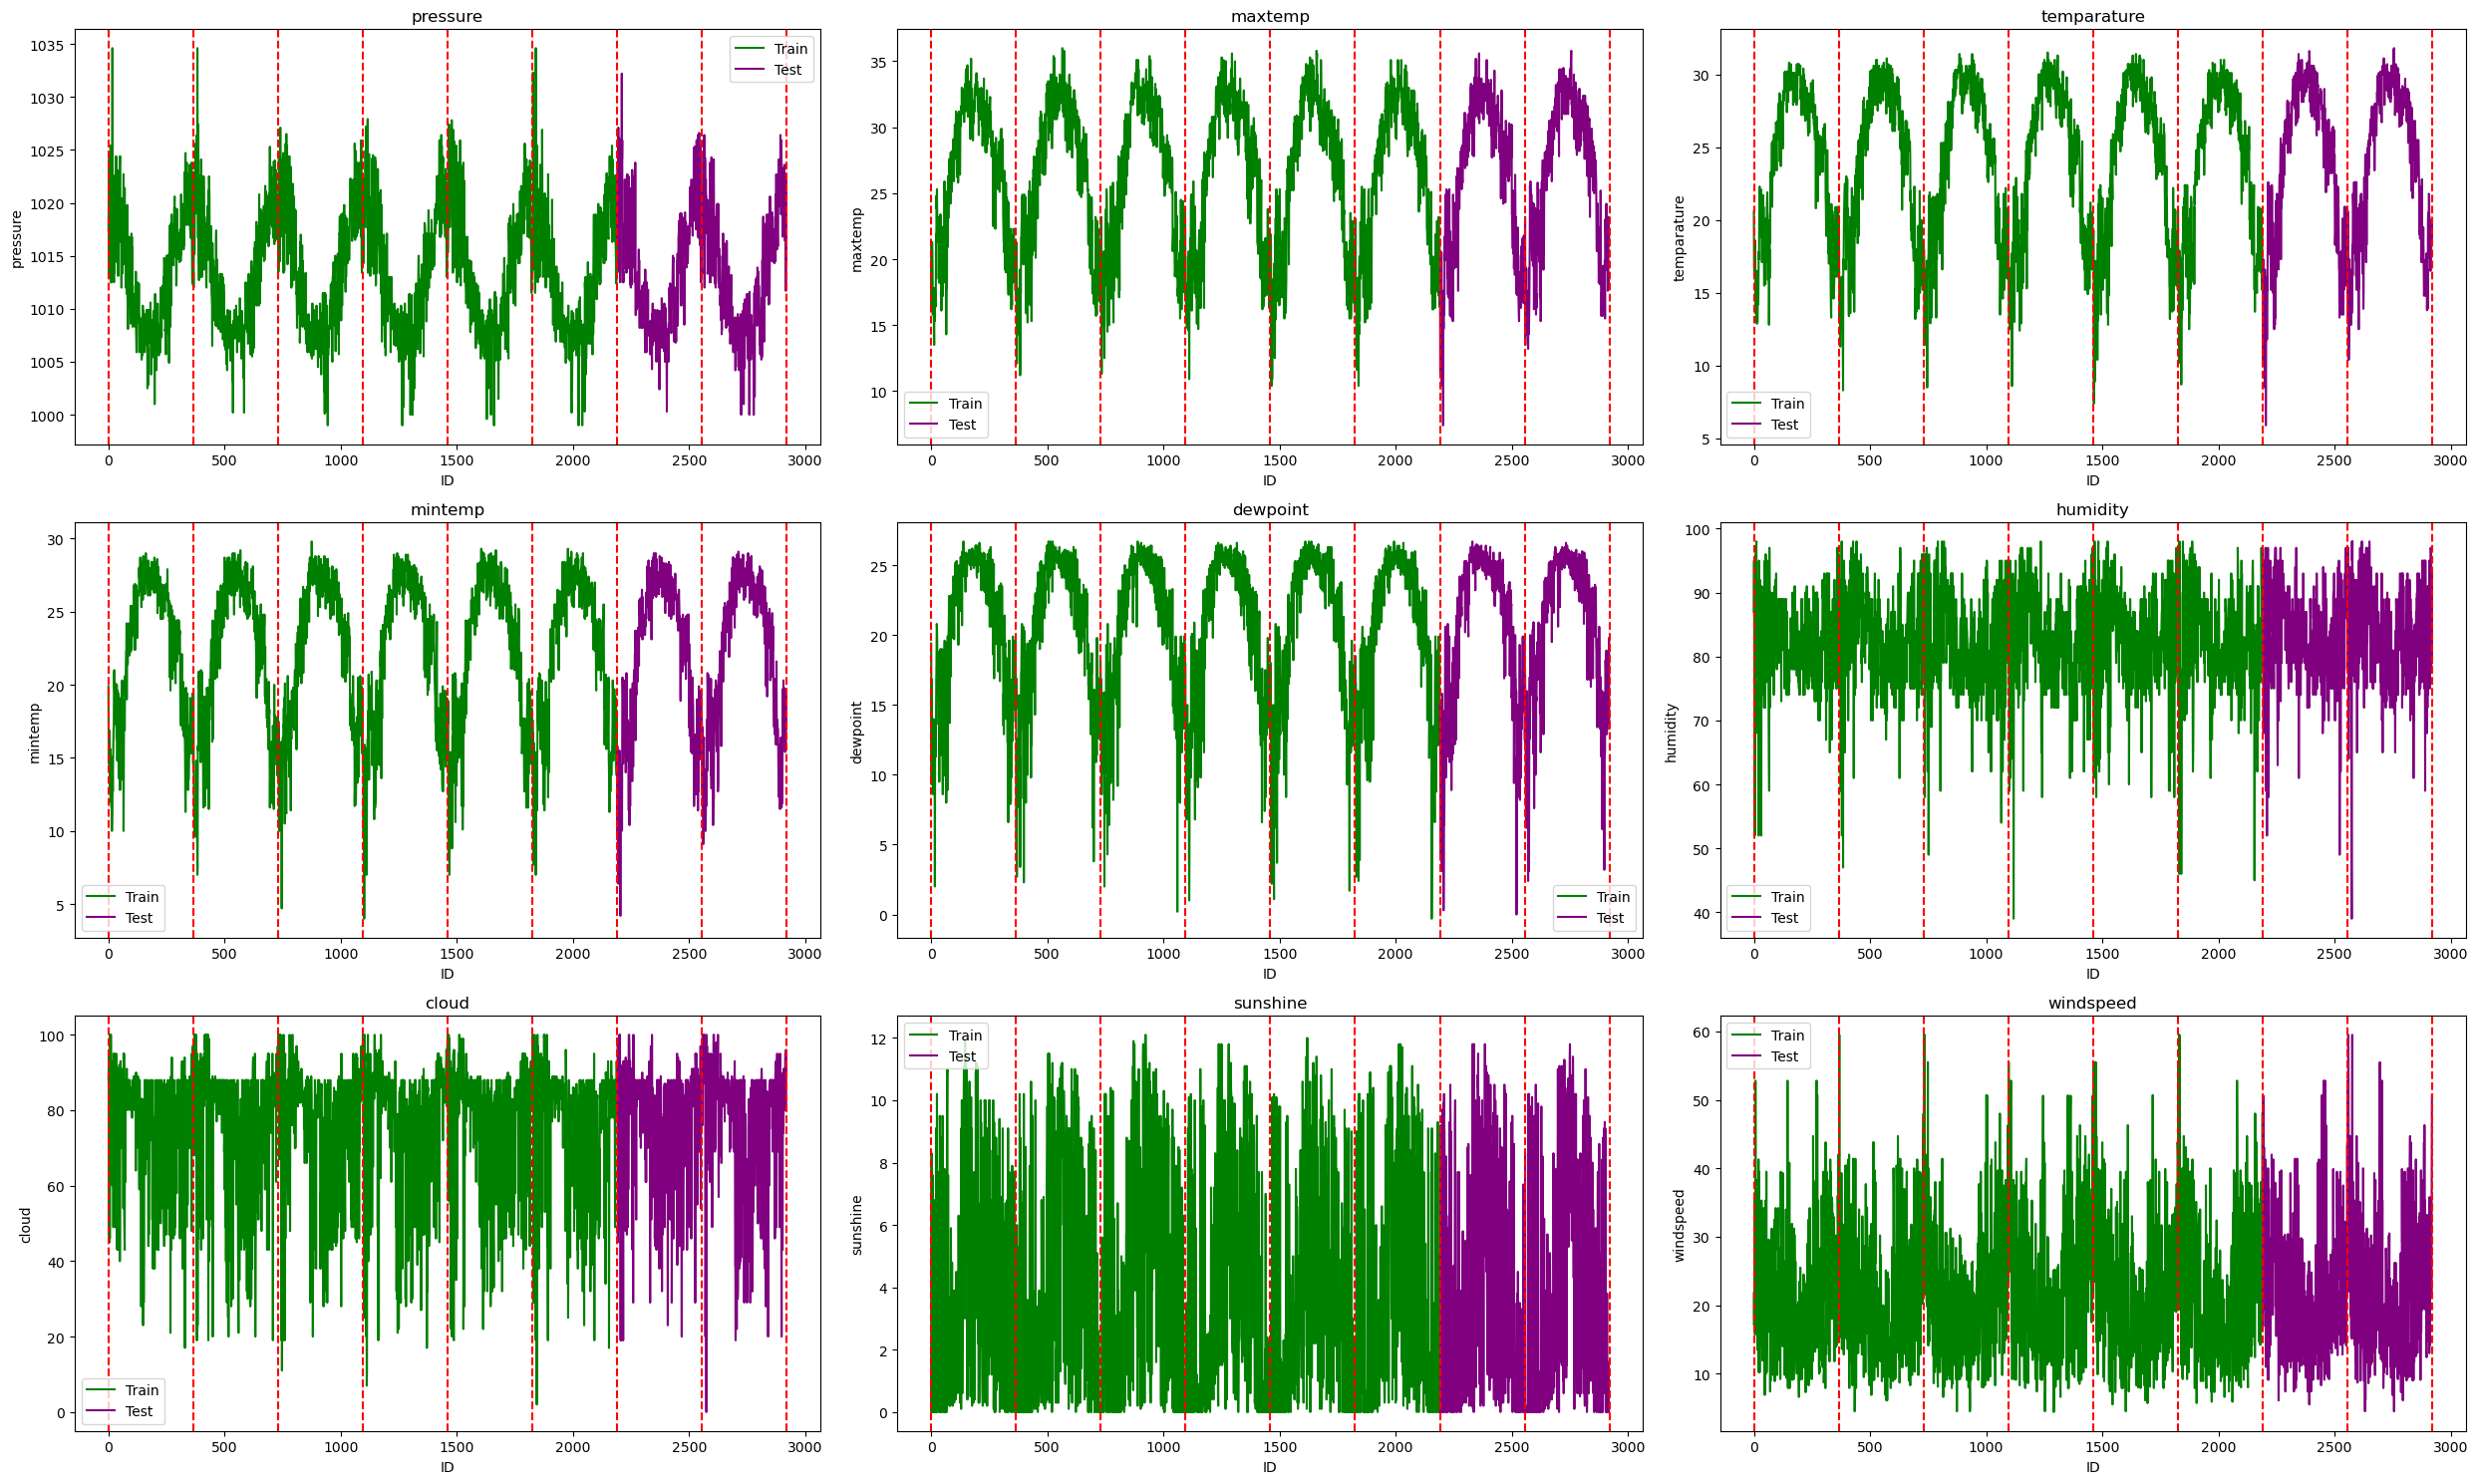

In [36]:
feature_list = [item for item in df_train.columns if item not in ['id', 'day', 'day_repaired', 'rainfall', 'winddirection']]

fig, axes = plt.subplots(3, 3, figsize=(25, 15))
axes = axes.flatten()
lines = [x for x in range(0, max(df_test['id']) + 364, 365)]
for i, feature in enumerate(feature_list):
    axes[i].plot(df_train['id'], df_train[feature], color='green')
    axes[i].plot(df_test['id'], df_test[feature], color='purple')
    for x in lines:
        axes[i].axvline(x=x, color='red', linestyle='--')
    axes[i].set_title(feature)
    axes[i].set_xlabel('ID')
    axes[i].set_ylabel(feature)
    axes[i].legend(['Train', 'Test'])

plt.tight_layout()
plt.show()

We see that the pattern is cyclical. Now we can transform the 'day' column.

In [37]:
def transform_circular(data, column):
    new_data = data.copy()
    new_data[column + '_sin'] = np.sin(2 * np.pi * new_data[column] / max(new_data[column]))
    new_data[column + '_cos'] = np.cos(2 * np.pi * new_data[column] / max(new_data[column]))
    return new_data

In [38]:
train = transform_circular(df_train, 'day_repaired')
train = transform_circular(train, 'winddirection')
train.drop(['id', 'day', 'day_repaired', 'winddirection'], axis=1, inplace=True)
train.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,windspeed,rainfall,day_repaired_sin,day_repaired_cos,winddirection_sin,winddirection_cos
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,17.2,1,0.000000,1.000000,0.951057,0.309017
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,21.9,1,0.017261,0.999851,0.866025,0.500000
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,18.1,1,0.034516,0.999404,0.994522,0.104528
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,35.6,1,0.051761,0.998659,0.951057,0.309017
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,24.8,0,0.068991,0.997617,0.743145,0.669131


In [44]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pressure           2190 non-null   float64
 1   maxtemp            2190 non-null   float64
 2   temparature        2190 non-null   float64
 3   mintemp            2190 non-null   float64
 4   dewpoint           2190 non-null   float64
 5   humidity           2190 non-null   float64
 6   cloud              2190 non-null   float64
 7   sunshine           2190 non-null   float64
 8   windspeed          2190 non-null   float64
 9   rainfall           2190 non-null   int64  
 10  day_repaired_sin   2190 non-null   float64
 11  day_repaired_cos   2190 non-null   float64
 12  winddirection_sin  2190 non-null   float64
 13  winddirection_cos  2190 non-null   float64
dtypes: float64(13), int64(1)
memory usage: 239.7 KB


Ostateczna wersja danych to 'train'.

## Combinations of columns

In [39]:
import itertools

In [40]:
def generate_combinations(df, exclude_columns=[]):
    selected_columns = [col for col in df.columns if col not in exclude_columns]

    new_columns = {}
    
    for n in range(2, 3):
        for cols in itertools.combinations(selected_columns, n):
            col_combination = '_'.join(cols)
    
            # Addition
            new_columns[f'{col_combination}_plus'] = df[list(cols)].sum(axis=1)
    
            # Subtraction
            if n == 2:
                new_columns[f'{cols[0]}_minus_{cols[1]}'] = df[cols[0]] - df[cols[1]]
                new_columns[f'{cols[1]}_minus_{cols[0]}'] = df[cols[1]] - df[cols[0]]
            else:
                for pair in itertools.combinations(cols, 2):
                    new_columns[f'{pair[0]}_minus_{pair[1]}'] = df[pair[0]] - df[pair[1]]
                    new_columns[f'{pair[1]}_minus_{pair[0]}'] = df[pair[1]] - df[pair[0]]
    
            # Multiplication
            new_columns[f'{col_combination}_times'] = df[list(cols)].prod(axis=1)
    
            # Division
            if n == 2:
                new_columns[f'{cols[0]}_div_{cols[1]}'] = df[cols[0]] / df[cols[1]]
                new_columns[f'{cols[1]}_div_{cols[0]}'] = df[cols[1]] / df[cols[0]]
            else:
                for pair in itertools.combinations(cols, 2):
                    new_columns[f'{pair[0]}_div_{pair[1]}'] = df[pair[0]] / df[pair[1]]
                    new_columns[f'{pair[1]}_div_{pair[0]}'] = df[pair[1]] / df[pair[0]]
    
    df_new = pd.DataFrame(new_columns, index=df.index)
    
    df_comb = pd.concat([df, df_new], axis=1)
    df_comb.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_comb.fillna(0, inplace=True)
    return df_comb

In [43]:
train_combinations = generate_combinations(train, exclude_columns=['rainfall'])
train_combinations.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,windspeed,rainfall,...,winddirection_cos_minus_day_repaired_cos,day_repaired_cos_winddirection_cos_times,day_repaired_cos_div_winddirection_cos,winddirection_cos_div_day_repaired_cos,winddirection_sin_winddirection_cos_plus,winddirection_sin_minus_winddirection_cos,winddirection_cos_minus_winddirection_sin,winddirection_sin_winddirection_cos_times,winddirection_sin_div_winddirection_cos,winddirection_cos_div_winddirection_sin
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,17.2,1,...,-0.690983,0.309017,3.236068,0.309017,1.260074,0.642040,-0.642040,0.293893,3.077684,0.324920
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,21.9,1,...,-0.499851,0.499926,1.999702,0.500074,1.366025,0.366025,-0.366025,0.433013,1.732051,0.577350
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,18.1,1,...,-0.894876,0.104466,9.561072,0.104591,1.099050,0.889993,-0.889993,0.103956,9.514364,0.105104
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,35.6,1,...,-0.689642,0.308603,3.231730,0.309432,1.260074,0.642040,-0.642040,0.293893,3.077684,0.324920
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,24.8,0,...,-0.328487,0.667536,1.490916,0.670729,1.412275,0.074014,-0.074014,0.497261,1.110613,0.900404


final data to use is 'train_combinations'

## Adding data from the previous days

In [57]:
def add_prev_days(df):
    """
    This function creates `df_prev` dataframe from `df`, adding weather features from previous days. 
    It adds 3 types of new columns: 
    weather features from the previous day, 
    the average values of features from the previous two days, 
    and the average values from the previous three days. 

    Parameters:
    df (pd.DataFrame): Input table with weather features (without 'id' column).

    Returns:
    df_prev (pd.DataFrame): A new table containing the original data and features from the previous days.
    """

    df_prev = df.copy()
    
    columns_to_drop = [col for col in df.columns if any(keyword in col for keyword in ['day', 'rainfall'])]
    
    df_shifted1 = df_prev.shift(1)
    df_shifted1.drop(columns_to_drop, axis=1, inplace=True)

    df_prev = pd.concat([df_prev, df_shifted1.add_prefix("prev1_")], axis=1)

    columns_to_drop = [col for col in df_shifted1.columns if any(keyword in col for keyword in ['winddirection', 'rainfall'])]

    df_shifted1.drop(columns_to_drop, axis=1, inplace=True)

    columns_to_drop = [col for col in df.columns if any(keyword in col for keyword in ['day', 'winddirection', 'rainfall'])]

    df_shifted2 = df.shift(2)
    df_shifted2.drop(columns_to_drop, axis=1, inplace=True)

    df_shifted3 = df.shift(3)
    df_shifted3.drop(columns_to_drop, axis=1, inplace=True)

    df_avg2 = pd.concat([df_shifted1, df_shifted2]).groupby(level=0).mean()
    df_avg2[(df_shifted1.isna()) | (df_shifted2.isna())] = np.nan
    df_avg2 = df_avg2.add_prefix("avg2_")
    df_avg2 = df_avg2.round(1)

    df_avg3 = pd.concat([df_shifted1, df_shifted2, df_shifted3]).groupby(level=0).mean()
    df_avg3[(df_shifted1.isna()) | (df_shifted2.isna()) | (df_shifted3.isna())] = np.nan
    df_avg3 = df_avg3.add_prefix("avg3_")
    df_avg3 = df_avg3.round(1)

    df_prev = pd.concat([df_prev, df_avg2, df_avg3], axis=1)
    # remember that first three records will have NaNs in columns from previous days

    return df_prev

In [58]:
train_prev = add_prev_days(train_combinations)
train_prev = train_prev.dropna().reset_index(drop=True)
train_prev

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,windspeed,rainfall,...,avg3_windspeed_minus_cloud,avg3_cloud_windspeed_times,avg3_cloud_div_windspeed,avg3_windspeed_div_cloud,avg3_sunshine_windspeed_plus,avg3_sunshine_minus_windspeed,avg3_windspeed_minus_sunshine,avg3_sunshine_windspeed_times,avg3_sunshine_div_windspeed,avg3_windspeed_div_sunshine
0,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,35.6,1,...,-56.3,1452.4,4.0,0.3,22.2,-15.9,15.9,56.4,0.2,5.9
1,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,24.8,0,...,-52.5,2075.2,3.1,0.3,28.0,-22.4,22.4,50.1,0.2,0.7
2,1022.7,20.6,18.6,16.5,12.5,79.0,81.0,0.0,15.7,1,...,-36.2,1782.9,2.4,0.4,30.1,-22.2,22.2,79.8,0.2,3.0
3,1022.8,19.5,18.4,15.3,11.3,56.0,46.0,7.6,28.4,0,...,-48.3,1923.2,3.2,0.4,26.6,-24.2,24.2,29.8,0.0,2.3
4,1019.7,15.8,13.6,12.7,11.8,96.0,100.0,0.0,52.8,1,...,-34.4,1231.4,2.9,0.5,26.7,-19.2,19.2,101.7,0.1,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2182,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,22.1,1,...,-55.7,2677.3,2.9,0.4,32.2,-29.8,29.8,41.0,0.0,11.5
2183,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,35.3,1,...,-56.4,2609.9,3.0,0.4,31.1,-29.4,29.4,31.1,0.0,78.9
2184,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,32.9,1,...,-58.7,2581.3,3.1,0.3,29.4,-29.3,29.3,0.7,0.0,73.7
2185,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,18.0,1,...,-54.9,2550.1,3.0,0.4,31.8,-28.4,28.4,55.6,0.1,75.9


final data to use is 'train_prev'

In [59]:
X_train_prev = train_prev.drop('rainfall', axis=1)
Y_train_prev = train_prev['rainfall']
X_train_prev.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,windspeed,day_repaired_sin,...,avg3_windspeed_minus_cloud,avg3_cloud_windspeed_times,avg3_cloud_div_windspeed,avg3_windspeed_div_cloud,avg3_sunshine_windspeed_plus,avg3_sunshine_minus_windspeed,avg3_windspeed_minus_sunshine,avg3_sunshine_windspeed_times,avg3_sunshine_div_windspeed,avg3_windspeed_div_sunshine
0,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,35.6,0.051761,...,-56.3,1452.4,4.0,0.3,22.2,-15.9,15.9,56.4,0.2,5.9
1,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,24.8,0.068991,...,-52.5,2075.2,3.1,0.3,28.0,-22.4,22.4,50.1,0.2,0.7
2,1022.7,20.6,18.6,16.5,12.5,79.0,81.0,0.0,15.7,0.086200,...,-36.2,1782.9,2.4,0.4,30.1,-22.2,22.2,79.8,0.2,3.0
3,1022.8,19.5,18.4,15.3,11.3,56.0,46.0,7.6,28.4,0.103384,...,-48.3,1923.2,3.2,0.4,26.6,-24.2,24.2,29.8,0.0,2.3
4,1019.7,15.8,13.6,12.7,11.8,96.0,100.0,0.0,52.8,0.120537,...,-34.4,1231.4,2.9,0.5,26.7,-19.2,19.2,101.7,0.1,3.5


# PCA

In [60]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Explained variance ratio for each component: [0.35516725 0.12696389 0.05782719 0.05271594 0.02996605 0.02522003
 0.0234326  0.01728066 0.01552691 0.01459867 0.01397756 0.01176274
 0.01146436 0.01062576 0.0104279  0.00970185 0.00948621 0.00924623
 0.00902504 0.00868826 0.00846898 0.00804717 0.00767077 0.00734037
 0.00731968 0.00700051 0.00672814 0.00646838 0.00616977 0.00575269
 0.0053415  0.00512164]
Total variance explained by the components: 0.9045346783249382
Transformed data (first 5 rows): 
[[ 2.48799231e+01  9.70662013e+00 -1.85587008e+01 -5.85964637e-01
   4.61167581e+00  1.76526039e+00 -5.59520117e+00 -8.04902314e+00
   6.70729964e+00  2.37782360e+00 -5.82543756e-01 -2.60621165e+00
  -2.59839797e+00 -2.21011609e+00 -4.33224528e+00  5.42224579e-01
   8.85393107e-01  4.78443508e+00  2.60921590e+00 -3.33038524e+00
  -1.43871057e+00 -2.33764707e-01  1.24842940e+00 -1.91014969e+00
   8.48258131e-01 -1.09101738e+00 -1.54424644e+00  1.78431816e+00
  -4.80513757e-01  4.44972019e+00 -2.

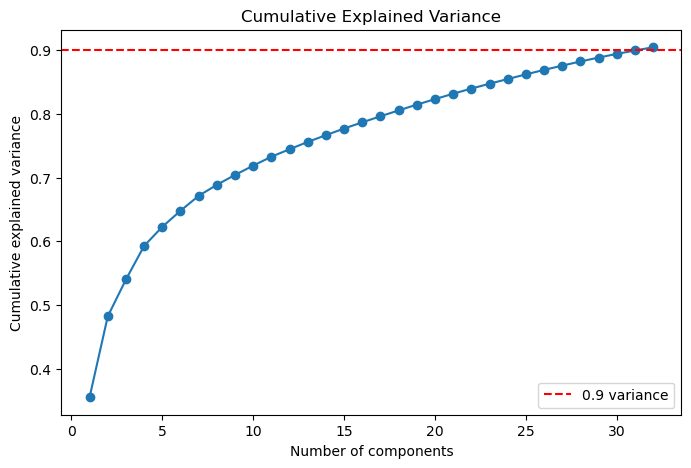

In [61]:
X = X_train_prev

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

var = 0.9
pca = PCA(n_components=var)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ratio for each component: {pca.explained_variance_ratio_}")
print(f"Total variance explained by the components: {sum(pca.explained_variance_ratio_)}")
print(f"Transformed data (first 5 rows): \n{X_pca[:5]}")

cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(cum_var) + 1), cum_var, marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.axhline(y=var, color='r', linestyle='--', label=f'{var} variance')
plt.legend()
plt.title("Cumulative Explained Variance")
plt.show()

In [62]:
n_components = np.argmax(cum_var >= 0.9) + 1
n_components

32

# Random Forest

In [63]:
from sklearn.ensemble import RandomForestClassifier

In [64]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_prev, Y_train_prev)

importances = clf.feature_importances_
features_importance = pd.Series(importances, index=X_train_prev.columns).sort_values(ascending=False)

print(features_importance)

dewpoint_cloud_plus              0.021990
temparature_cloud_plus           0.021380
day_repaired_cos_minus_cloud     0.019618
pressure_div_cloud               0.018183
cloud_winddirection_sin_plus     0.016697
                                   ...   
avg3_humidity_div_pressure       0.000000
avg3_dewpoint_div_pressure       0.000000
avg3_temparature_div_humidity    0.000000
avg3_maxtemp_div_pressure        0.000000
avg2_mintemp_div_pressure        0.000000
Length: 1272, dtype: float64


In [65]:
df = features_importance.head(50).reset_index().rename(columns={"index": "Feature", 0: "Importance"})
df.index = range(1, 1 + len(df))
df

,Feature,Importance
1,dewpoint_cloud_plus,0.021990
2,temparature_cloud_plus,0.021380
3,day_repaired_cos_minus_cloud,0.019618
4,pressure_div_cloud,0.018183
5,cloud_winddirection_sin_plus,0.016697
6,mintemp_cloud_plus,0.016214
7,pressure_cloud_times,0.014539
8,pressure_minus_cloud,0.014353
9,humidity_cloud_plus,0.014090
10,humidity_cloud_times,0.014079


In [66]:
df = features_importance.iloc[50:100].reset_index().rename(columns={"index": "Feature", 0: "Importance"})
df.index = range(51, 51 + len(df))
df

,Feature,Importance
51,cloud_div_temparature,0.003102
52,mintemp_div_cloud,0.003089
53,day_repaired_sin_minus_humidity,0.002817
54,sunshine_div_dewpoint,0.002529
55,pressure_div_humidity,0.002491
56,dewpoint_minus_sunshine,0.002488
57,maxtemp_sunshine_times,0.002373
58,sunshine_day_repaired_sin_plus,0.002316
59,day_repaired_sin_minus_cloud,0.002058
60,sunshine_winddirection_sin_plus,0.001988


In [67]:
df = features_importance.iloc[100:150].reset_index().rename(columns={"index": "Feature", 0: "Importance"})
df.index = range(101, 101 + len(df))
df

,Feature,Importance
101,maxtemp_div_mintemp,0.001078
102,prev1_temparature_windspeed_times,0.001077
103,day_repaired_cos_minus_winddirection_cos,0.001072
104,day_repaired_sin_div_dewpoint,0.001065
105,maxtemp_div_sunshine,0.001065
106,humidity_div_dewpoint,0.001050
107,windspeed_minus_cloud,0.001048
108,winddirection_cos_minus_day_repaired_cos,0.001046
109,day_repaired_cos_div_cloud,0.001040
110,humidity_sunshine_times,0.001031


In [68]:
df = features_importance.iloc[150:200].reset_index().rename(columns={"index": "Feature", 0: "Importance"})
df.index = range(151, 151 + len(df))
df

,Feature,Importance
151,cloud_div_day_repaired_cos,0.000861
152,winddirection_sin_div_maxtemp,0.000857
153,avg2_pressure_maxtemp_plus,0.000855
154,avg2_maxtemp_temparature_plus,0.000846
155,prev1_temparature_winddirection_sin_times,0.000844
156,prev1_sunshine_winddirection_cos_plus,0.000843
157,winddirection_cos_div_temparature,0.000842
158,dewpoint_day_repaired_cos_plus,0.000838
159,prev1_pressure_winddirection_sin_times,0.000836
160,avg3_pressure_temparature_plus,0.000833


In [69]:
df = features_importance.tail(60).reset_index().rename(columns={"index": "Feature", 0: "Importance"})
df.index = range(1214, 1214 + len(df))
df

,Feature,Importance
1214,avg3_maxtemp_minus_humidity,0.000084
1215,avg2_sunshine_div_temparature,0.000082
1216,avg3_cloud_minus_maxtemp,0.000081
1217,avg2_mintemp_div_windspeed,0.000080
1218,avg2_cloud_div_maxtemp,0.000080
1219,avg3_mintemp_div_dewpoint,0.000073
1220,avg3_sunshine_div_dewpoint,0.000072
1221,winddirection_sin,0.000068
1222,avg2_maxtemp_div_dewpoint,0.000067
1223,avg2_maxtemp_div_mintemp,0.000066
